# 🧠 PULSE — Personal Performance Intelligence System
## ML Pipeline (OOP Edition)

**Three models. One pipeline. Zero guesswork.**

| Model | Type | Target | Output |
|---|---|---|---|
| `ProductivityPredictor` | Linear Regression | `productivity_score` | 0–100 score |
| `BurnoutClassifier` | Logistic Regression | `burnout_risk` | Low / Medium / High |
| `PersonaEngine` | K-Means Clustering | Lifestyle cluster | Persona label |

---


In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import os

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.cluster import KMeans
from sklearn.metrics import (
    mean_squared_error, r2_score,
    classification_report, confusion_matrix,
    silhouette_score
)

print("✅ All libraries imported successfully")


✅ All libraries imported successfully


## 📦 Step 1 — Data Loader

In [8]:
class DataLoader:
    """Loads and validates the PULSE dataset."""

    FEATURE_COLS = [
        'sleep_hours', 'study_hours', 'screen_time_hours',
        'exercise_mins', 'mood_score', 'stress_level',
        'caffeine_intake', 'water_litres', 'deep_focus_blocks',
        'social_media_mins'
    ]
    TARGET_PRODUCTIVITY = 'productivity_score'
    TARGET_BURNOUT      = 'burnout_risk'

    def __init__(self, path: str):
        self.path = path
        self.df   = None

    def load(self):
        self.df = pd.read_csv(self.path)
        print(f"✅ Dataset loaded: {self.df.shape[0]:,} rows × {self.df.shape[1]} columns")
        return self

    def summary(self):
        print("\n📊 Dataset Overview")
        print("─" * 40)
        print(f"  Rows       : {len(self.df):,}")
        print(f"  Users      : {self.df['user_id'].nunique()}")
        print(f"  Date range : {self.df['date'].min()} → {self.df['date'].max()}")

        print("\n🧬 Persona Distribution (users):")
        print(self.df.drop_duplicates('user_id')['persona'].value_counts().to_string())

        print("\n🔴 Burnout Risk Distribution:")
        counts = self.df[self.TARGET_BURNOUT].value_counts()
        pcts   = self.df[self.TARGET_BURNOUT].value_counts(normalize=True).mul(100).round(1)
        for label in counts.index:
            print(f"  {label:8s}: {counts[label]:,}  ({pcts[label]}%)")

        print("\n📈 Productivity Score Stats:")
        print(self.df[self.TARGET_PRODUCTIVITY].describe().round(2).to_string())

    def get_data(self):
        return self.df


# ── Run ──
loader = DataLoader('pulse_dataset.csv')
loader.load().summary()
df = loader.get_data()


✅ Dataset loaded: 100,000 rows × 17 columns

📊 Dataset Overview
────────────────────────────────────────
  Rows       : 100,000
  Users      : 500
  Date range : 2024-01-01 → 2024-07-18

🧬 Persona Distribution (users):
persona
low_sleep         125
balanced          125
high_stress       125
high_performer    125

🔴 Burnout Risk Distribution:
  Low     : 50,290  (50.3%)
  Medium  : 33,440  (33.4%)
  High    : 16,270  (16.3%)

📈 Productivity Score Stats:
count    100000.00
mean         63.12
std          22.85
min           3.00
25%          44.40
50%          59.30
75%          81.60
max         100.00


## 📈 Step 2 — Model 1: Productivity Predictor (Linear Regression)

📈 Productivity Predictor — Evaluation
────────────────────────────────────────
  R² Score : 0.9766
  RMSE     : 3.5262

  Top Feature Influences:
          Feature  Coefficient
      study_hours     6.555754
      sleep_hours     6.399136
     stress_level    -4.783896
       mood_score     4.442394
screen_time_hours    -3.610617
deep_focus_blocks     2.238091
    exercise_mins     1.932109
  caffeine_intake    -1.566908
     water_litres     1.049254
social_media_mins     0.079926


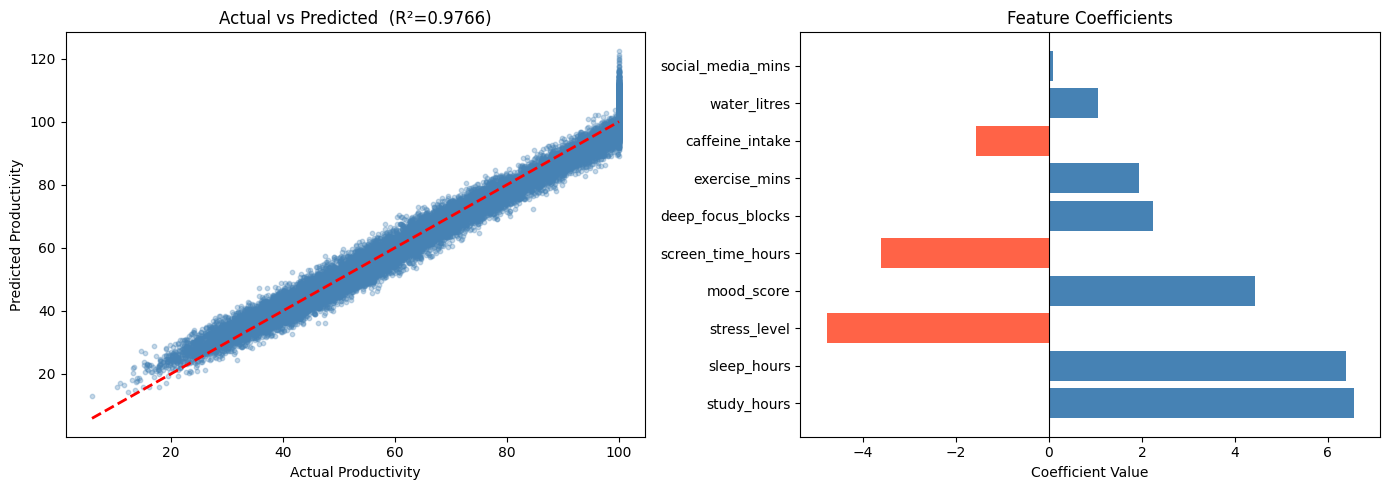

In [9]:
class ProductivityPredictor:
    """
    Predicts a continuous productivity score (0–100)
    using Multiple Linear Regression.
    """

    FEATURES = DataLoader.FEATURE_COLS

    def __init__(self):
        self.model   = LinearRegression()
        self.scaler  = StandardScaler()
        self.is_fit  = False
        self.metrics = {}

    # ── Train ──────────────────────────────────────────
    def fit(self, df: pd.DataFrame, test_size=0.2, random_state=42):
        X = df[self.FEATURES]
        y = df[DataLoader.TARGET_PRODUCTIVITY]

        X_train, X_test, y_train, y_test = train_test_split(
            X, y, test_size=test_size, random_state=random_state
        )

        X_train_sc = self.scaler.fit_transform(X_train)
        X_test_sc  = self.scaler.transform(X_test)

        self.model.fit(X_train_sc, y_train)
        self.is_fit = True

        y_pred = self.model.predict(X_test_sc)
        self.metrics = {
            'R2'  : round(r2_score(y_test, y_pred), 4),
            'RMSE': round(np.sqrt(mean_squared_error(y_test, y_pred)), 4)
        }

        self._X_test  = X_test_sc
        self._y_test  = y_test
        self._y_pred  = y_pred
        return self

    # ── Evaluate ───────────────────────────────────────
    def evaluate(self):
        print("📈 Productivity Predictor — Evaluation")
        print("─" * 40)
        print(f"  R² Score : {self.metrics['R2']}")
        print(f"  RMSE     : {self.metrics['RMSE']}")

        # Coefficient importance
        coef_df = pd.DataFrame({
            'Feature'    : self.FEATURES,
            'Coefficient': self.model.coef_
        }).sort_values('Coefficient', key=abs, ascending=False)

        print("\n  Top Feature Influences:")
        print(coef_df.to_string(index=False))

        # Plot: Actual vs Predicted
        fig, axes = plt.subplots(1, 2, figsize=(14, 5))

        axes[0].scatter(self._y_test, self._y_pred, alpha=0.3, color='steelblue', s=10)
        axes[0].plot(
            [self._y_test.min(), self._y_test.max()],
            [self._y_test.min(), self._y_test.max()],
            'r--', lw=2
        )
        axes[0].set_xlabel('Actual Productivity')
        axes[0].set_ylabel('Predicted Productivity')
        axes[0].set_title(f'Actual vs Predicted  (R²={self.metrics["R2"]})')

        axes[1].barh(coef_df['Feature'], coef_df['Coefficient'],
                     color=['tomato' if c < 0 else 'steelblue' for c in coef_df['Coefficient']])
        axes[1].axvline(0, color='black', linewidth=0.8)
        axes[1].set_title('Feature Coefficients')
        axes[1].set_xlabel('Coefficient Value')

        plt.tight_layout()
        plt.show()

    # ── Predict ────────────────────────────────────────
    def predict(self, user_input: dict) -> float:
        """Predict productivity for a single user input dict."""
        x = pd.DataFrame([user_input])[self.FEATURES]
        x_sc = self.scaler.transform(x)
        score = self.model.predict(x_sc)[0]
        return round(float(np.clip(score, 0, 100)), 1)

    # ── Save ───────────────────────────────────────────
    def save(self, model_path='productivity_model.pkl', scaler_path='productivity_scaler.pkl'):
        with open(model_path,  'wb') as f: pickle.dump(self.model,  f)
        with open(scaler_path, 'wb') as f: pickle.dump(self.scaler, f)
        print(f"  💾 Saved: {model_path}, {scaler_path}")

    # ── Load ───────────────────────────────────────────
    @classmethod
    def load(cls, model_path='productivity_model.pkl', scaler_path='productivity_scaler.pkl'):
        obj = cls()
        with open(model_path,  'rb') as f: obj.model  = pickle.load(f)
        with open(scaler_path, 'rb') as f: obj.scaler = pickle.load(f)
        obj.is_fit = True
        return obj


# ── Run ──
productivity_model = ProductivityPredictor()
productivity_model.fit(df)
productivity_model.evaluate()


## 🔴 Step 3 — Model 2: Burnout Classifier (Logistic Regression)

c:\Users\Ravin\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


🔴 Burnout Classifier — Evaluation
────────────────────────────────────────
              precision    recall  f1-score   support

        High       0.87      0.82      0.84      3254
         Low       1.00      1.00      1.00     10058
      Medium       0.91      0.94      0.92      6688

    accuracy                           0.95     20000
   macro avg       0.92      0.92      0.92     20000
weighted avg       0.95      0.95      0.95     20000



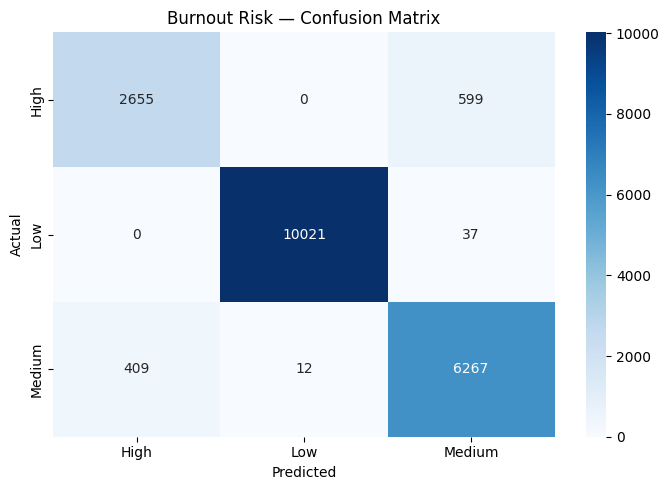

In [10]:
class BurnoutClassifier:
    """
    Classifies burnout risk as Low / Medium / High
    using Multinomial Logistic Regression.
    """

    BASE_FEATURES = DataLoader.FEATURE_COLS
    EXTRA_FEATURES = ['is_weekend', 'day_of_week']   # day_of_week gets one-hot encoded

    def __init__(self):
        self.model          = LogisticRegression(multi_class='multinomial', max_iter=1000)
        self.scaler         = StandardScaler()
        self.label_encoder  = LabelEncoder()
        self.feature_cols   = None   # set after encoding
        self.is_fit         = False

    # ── Train ──────────────────────────────────────────
    def fit(self, df: pd.DataFrame, test_size=0.2, random_state=42):
        X = df[self.BASE_FEATURES + self.EXTRA_FEATURES].copy()
        X = pd.get_dummies(X, columns=['day_of_week'])
        self.feature_cols = X.columns.tolist()

        y = self.label_encoder.fit_transform(df[DataLoader.TARGET_BURNOUT])

        X_train, X_test, y_train, y_test = train_test_split(
            X, y, test_size=test_size, random_state=random_state, stratify=y
        )

        X_train_sc = self.scaler.fit_transform(X_train)
        X_test_sc  = self.scaler.transform(X_test)

        self.model.fit(X_train_sc, y_train)
        self.is_fit = True

        self._y_test  = y_test
        self._y_pred  = self.model.predict(X_test_sc)
        self._X_test  = X_test_sc
        return self

    # ── Evaluate ───────────────────────────────────────
    def evaluate(self):
        class_names = self.label_encoder.classes_
        print("🔴 Burnout Classifier — Evaluation")
        print("─" * 40)
        print(classification_report(
            self._y_test, self._y_pred,
            target_names=class_names
        ))

        # Confusion matrix
        cm = confusion_matrix(self._y_test, self._y_pred)
        plt.figure(figsize=(7, 5))
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                    xticklabels=class_names, yticklabels=class_names)
        plt.title('Burnout Risk — Confusion Matrix')
        plt.xlabel('Predicted')
        plt.ylabel('Actual')
        plt.tight_layout()
        plt.show()

    # ── Predict ────────────────────────────────────────
    def predict(self, user_input: dict):
        """
        Returns (risk_label, confidence_dict).
        user_input must include 'day_of_week' and 'is_weekend'.
        """
        x = pd.DataFrame([user_input])[self.BASE_FEATURES + self.EXTRA_FEATURES].copy()
        x = pd.get_dummies(x, columns=['day_of_week'])
        for col in self.feature_cols:
            if col not in x.columns:
                x[col] = 0
        x = x[self.feature_cols]
        x_sc = self.scaler.transform(x)

        label = self.label_encoder.inverse_transform(self.model.predict(x_sc))[0]
        probs = self.model.predict_proba(x_sc)[0]
        confidence = {
            cls: f"{p:.1%}"
            for cls, p in zip(self.label_encoder.classes_, probs)
        }
        return label, confidence

    # ── Save ───────────────────────────────────────────
    def save(self, dir='.'):
        paths = {
            'model'        : os.path.join(dir, 'burnout_model.pkl'),
            'scaler'       : os.path.join(dir, 'burnout_scaler.pkl'),
            'label_encoder': os.path.join(dir, 'burnout_label_encoder.pkl'),
            'feature_cols' : os.path.join(dir, 'burnout_feature_cols.pkl'),
        }
        for key, path in paths.items():
            with open(path, 'wb') as f:
                pickle.dump(getattr(self, key if key != 'model' else 'model'), f)
        with open(paths['scaler'],        'wb') as f: pickle.dump(self.scaler,        f)
        with open(paths['label_encoder'], 'wb') as f: pickle.dump(self.label_encoder, f)
        with open(paths['feature_cols'],  'wb') as f: pickle.dump(self.feature_cols,  f)
        with open(paths['model'],         'wb') as f: pickle.dump(self.model,         f)
        print(f"  💾 Saved burnout model files to: {dir}")

    # ── Load ───────────────────────────────────────────
    @classmethod
    def load(cls, dir='.'):
        obj = cls()
        with open(os.path.join(dir, 'burnout_model.pkl'),         'rb') as f: obj.model         = pickle.load(f)
        with open(os.path.join(dir, 'burnout_scaler.pkl'),        'rb') as f: obj.scaler        = pickle.load(f)
        with open(os.path.join(dir, 'burnout_label_encoder.pkl'), 'rb') as f: obj.label_encoder = pickle.load(f)
        with open(os.path.join(dir, 'burnout_feature_cols.pkl'),  'rb') as f: obj.feature_cols  = pickle.load(f)
        obj.is_fit = True
        return obj


# ── Run ──
burnout_model = BurnoutClassifier()
burnout_model.fit(df)
burnout_model.evaluate()


## 👤 Step 4 — Model 3: Persona Engine (K-Means Clustering)

🔍 Finding optimal number of clusters...


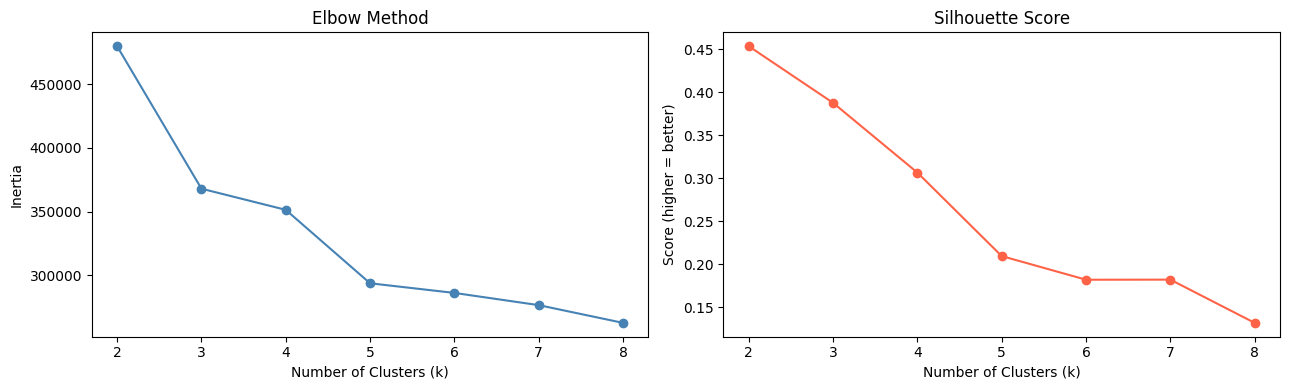


  Recommended k = 2  (highest silhouette score)


2

In [11]:
class PersonaEngine:
    """
    Groups users into lifestyle personas using K-Means clustering.
    Automatically selects optimal k using the Elbow + Silhouette method.
    """

    FEATURES = DataLoader.FEATURE_COLS

    PERSONA_LABELS = {
        # Will be assigned after inspecting cluster centroids
        0: 'Balanced Performer',
        1: 'High Stress Grinder',
        2: 'Low Energy Drifter',
        3: 'Peak Optimizer',
    }

    def __init__(self, k=4):
        self.k       = k
        self.model   = KMeans(n_clusters=k, random_state=42, n_init='auto')
        self.scaler  = StandardScaler()
        self.is_fit  = False

    # ── Find optimal k ─────────────────────────────────
    @staticmethod
    def find_optimal_k(df: pd.DataFrame, k_range=range(2, 9)):
        X = df[DataLoader.FEATURE_COLS]
        scaler = StandardScaler()
        X_sc = scaler.fit_transform(X)

        inertias    = []
        silhouettes = []

        for k in k_range:
            km = KMeans(n_clusters=k, random_state=42, n_init='auto')
            labels = km.fit_predict(X_sc)
            inertias.append(km.inertia_)
            silhouettes.append(silhouette_score(X_sc, labels, sample_size=5000))

        fig, axes = plt.subplots(1, 2, figsize=(13, 4))

        axes[0].plot(list(k_range), inertias, 'o-', color='steelblue')
        axes[0].set_title('Elbow Method')
        axes[0].set_xlabel('Number of Clusters (k)')
        axes[0].set_ylabel('Inertia')

        axes[1].plot(list(k_range), silhouettes, 'o-', color='tomato')
        axes[1].set_title('Silhouette Score')
        axes[1].set_xlabel('Number of Clusters (k)')
        axes[1].set_ylabel('Score (higher = better)')

        plt.tight_layout()
        plt.show()

        best_k = list(k_range)[int(np.argmax(silhouettes))]
        print(f"\n  Recommended k = {best_k}  (highest silhouette score)")
        return best_k

    # ── Train ──────────────────────────────────────────
    def fit(self, df: pd.DataFrame):
        # Aggregate per user (cluster on user-level averages)
        user_df = df.groupby('user_id')[self.FEATURES].mean()
        X_sc = self.scaler.fit_transform(user_df)

        self.model.fit(X_sc)
        self.is_fit = True

        user_df['cluster'] = self.model.labels_
        self._cluster_summary = user_df.groupby('cluster')[self.FEATURES].mean()
        self._user_df = user_df
        return self

    # ── Evaluate ───────────────────────────────────────
    def evaluate(self):
        X_sc = self.scaler.transform(self._user_df[self.FEATURES])
        score = silhouette_score(X_sc, self.model.labels_)

        print("👤 Persona Engine — Evaluation")
        print("─" * 40)
        print(f"  Silhouette Score : {score:.4f}  (closer to 1 = better)")
        print(f"  Number of clusters: {self.k}")

        print("\n  Cluster Sizes:")
        sizes = pd.Series(self.model.labels_).value_counts().sort_index()
        for i, s in sizes.items():
            print(f"    Cluster {i} ({self.PERSONA_LABELS.get(i,'?')}): {s} users")

        # Heatmap
        plt.figure(figsize=(12, 5))
        sns.heatmap(
            self._cluster_summary.T,
            annot=True, fmt='.2f', cmap='YlGnBu',
            xticklabels=[f"C{i}\n{self.PERSONA_LABELS.get(i,'')}" for i in self._cluster_summary.index]
        )
        plt.title('Feature Averages per Lifestyle Cluster')
        plt.tight_layout()
        plt.show()

    # ── Predict ────────────────────────────────────────
    def predict(self, user_input: dict) -> dict:
        """Classify a new user into a persona cluster."""
        x = pd.DataFrame([user_input])[self.FEATURES]
        x_sc = self.scaler.transform(x)
        cluster_id = int(self.model.predict(x_sc)[0])
        persona    = self.PERSONA_LABELS.get(cluster_id, f'Cluster {cluster_id}')
        return {'cluster_id': cluster_id, 'persona': persona}

    # ── Save ───────────────────────────────────────────
    def save(self, dir='.'):
        with open(os.path.join(dir, 'kmeans_model.pkl'),  'wb') as f: pickle.dump(self.model,  f)
        with open(os.path.join(dir, 'kmeans_scaler.pkl'), 'wb') as f: pickle.dump(self.scaler, f)
        print(f"  💾 Saved: kmeans_model.pkl, kmeans_scaler.pkl")

    # ── Load ───────────────────────────────────────────
    @classmethod
    def load(cls, k=4, dir='.'):
        obj = cls(k=k)
        with open(os.path.join(dir, 'kmeans_model.pkl'),  'rb') as f: obj.model  = pickle.load(f)
        with open(os.path.join(dir, 'kmeans_scaler.pkl'), 'rb') as f: obj.scaler = pickle.load(f)
        obj.is_fit = True
        return obj


# ── Step 1: Find optimal k ──
print("🔍 Finding optimal number of clusters...")
PersonaEngine.find_optimal_k(df)


👤 Persona Engine — Evaluation
────────────────────────────────────────
  Silhouette Score : 0.9313  (closer to 1 = better)
  Number of clusters: 4

  Cluster Sizes:
    Cluster 0 (Balanced Performer): 125 users
    Cluster 1 (High Stress Grinder): 125 users
    Cluster 2 (Low Energy Drifter): 125 users
    Cluster 3 (Peak Optimizer): 125 users


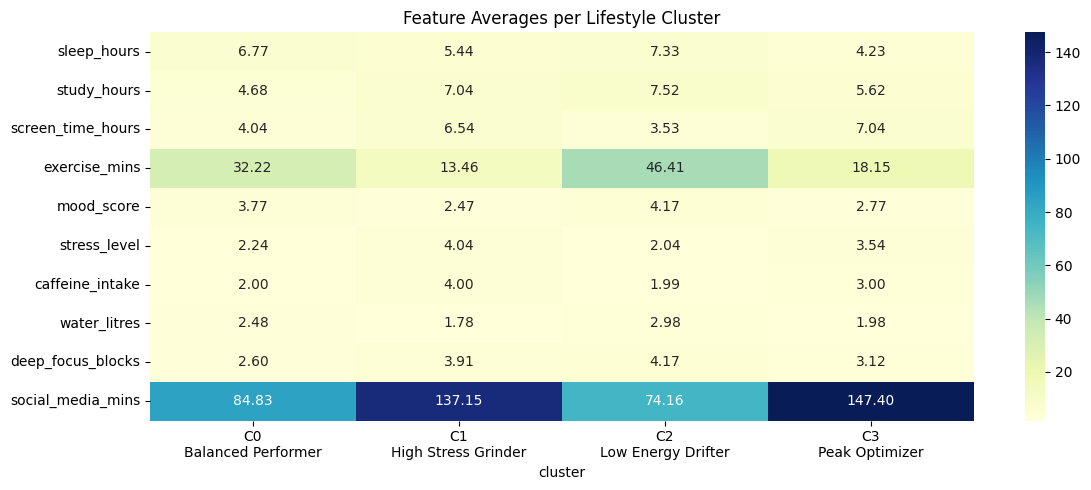

In [12]:
# ── Step 2: Train with chosen k (adjust if needed based on plot above) ──
persona_model = PersonaEngine(k=4)
persona_model.fit(df)
persona_model.evaluate()


## 🚀 Step 5 — Full PULSE Pipeline

In [14]:
class PulsePipeline:
    """
    Orchestrates all 3 models.
    Train → Evaluate → Save → Predict.
    """

    def __init__(self, data_path: str):
        self.data_path          = data_path
        self.loader             = DataLoader(data_path)
        self.productivity_model = ProductivityPredictor()
        self.burnout_model      = BurnoutClassifier()
        self.persona_model      = PersonaEngine(k=4)

    def train_all(self):
        print("=" * 50)
        print("  PULSE — Training All Models")
        print("=" * 50)
        df = self.loader.load().get_data()
        self.productivity_model.fit(df)
        print("  ✅ ProductivityPredictor trained")
        self.burnout_model.fit(df)
        print("  ✅ BurnoutClassifier trained")
        self.persona_model.fit(df)
        print("  ✅ PersonaEngine trained")
        return self

    def evaluate_all(self):
        print("\n" + "=" * 50)
        print("  PULSE — Evaluating All Models")
        print("=" * 50)
        self.productivity_model.evaluate()
        self.burnout_model.evaluate()
        self.persona_model.evaluate()
        return self

    def save_all(self, dir='/content/pulse_models'):
        os.makedirs(dir, exist_ok=True)
        print(f"\n💾 Saving all models to: {dir}")
        self.productivity_model.save(
            model_path  = os.path.join(dir, 'productivity_model.pkl'),
            scaler_path = os.path.join(dir, 'productivity_scaler.pkl')
        )
        self.burnout_model.save(dir=dir)
        self.persona_model.save(dir=dir)
        print("\n✅ All models saved successfully!")
        print("  Files created:")
        for f in sorted(os.listdir(dir)):
            print(f"    📁 {f}")
        return self

    def predict(self, user_input: dict) -> dict:
        """
        Run the full prediction pipeline for one user input.
        Returns productivity score, burnout risk, and persona.
        """
        productivity = self.productivity_model.predict(user_input)
        risk, confidence = self.burnout_model.predict(user_input)
        persona_info = self.persona_model.predict(user_input)

        result = {
            'productivity_score': productivity,
            'burnout_risk'      : risk,
            'burnout_confidence': confidence,
            'persona'           : persona_info['persona'],
            'cluster_id'        : persona_info['cluster_id'],
        }
        return result


# ── Run Full Pipeline ──
pipeline = PulsePipeline('pulse_dataset.csv')
pipeline.train_all()


  PULSE — Training All Models
✅ Dataset loaded: 100,000 rows × 17 columns
  ✅ ProductivityPredictor trained


c:\Users\Ravin\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


  ✅ BurnoutClassifier trained
  ✅ PersonaEngine trained



  PULSE — Evaluating All Models
📈 Productivity Predictor — Evaluation
────────────────────────────────────────
  R² Score : 0.9766
  RMSE     : 3.5262

  Top Feature Influences:
          Feature  Coefficient
      study_hours     6.555754
      sleep_hours     6.399136
     stress_level    -4.783896
       mood_score     4.442394
screen_time_hours    -3.610617
deep_focus_blocks     2.238091
    exercise_mins     1.932109
  caffeine_intake    -1.566908
     water_litres     1.049254
social_media_mins     0.079926


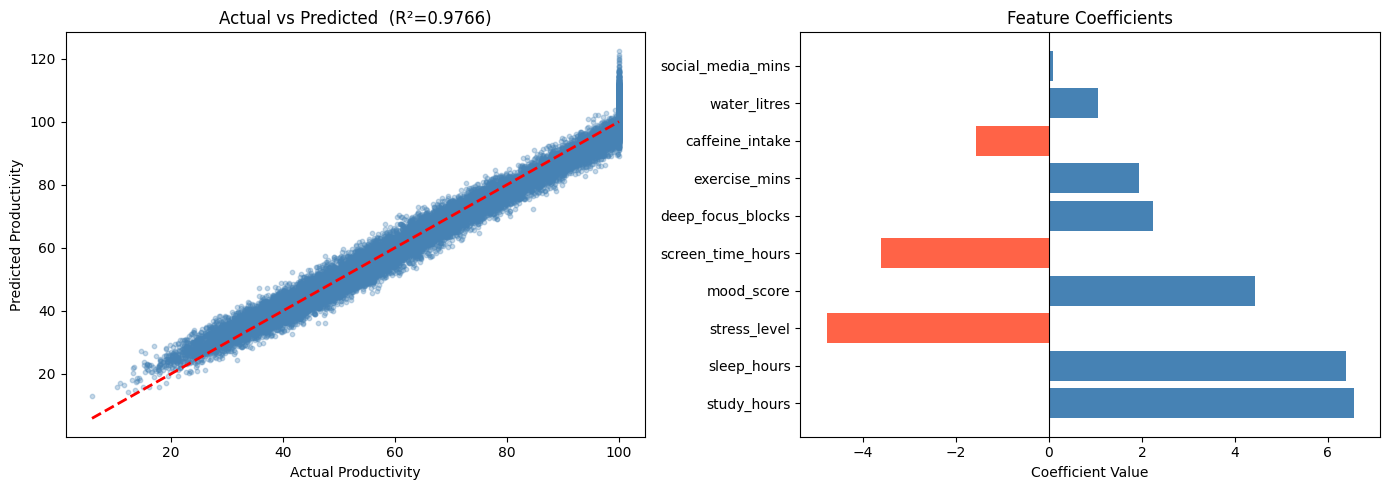

🔴 Burnout Classifier — Evaluation
────────────────────────────────────────
              precision    recall  f1-score   support

        High       0.87      0.82      0.84      3254
         Low       1.00      1.00      1.00     10058
      Medium       0.91      0.94      0.92      6688

    accuracy                           0.95     20000
   macro avg       0.92      0.92      0.92     20000
weighted avg       0.95      0.95      0.95     20000



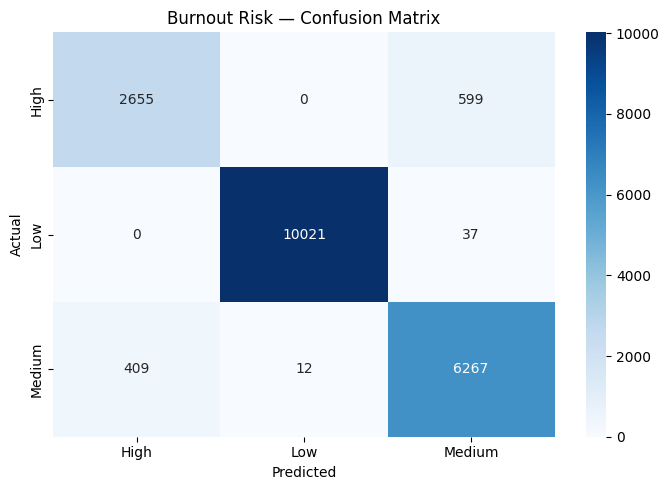

👤 Persona Engine — Evaluation
────────────────────────────────────────
  Silhouette Score : 0.9313  (closer to 1 = better)
  Number of clusters: 4

  Cluster Sizes:
    Cluster 0 (Balanced Performer): 125 users
    Cluster 1 (High Stress Grinder): 125 users
    Cluster 2 (Low Energy Drifter): 125 users
    Cluster 3 (Peak Optimizer): 125 users


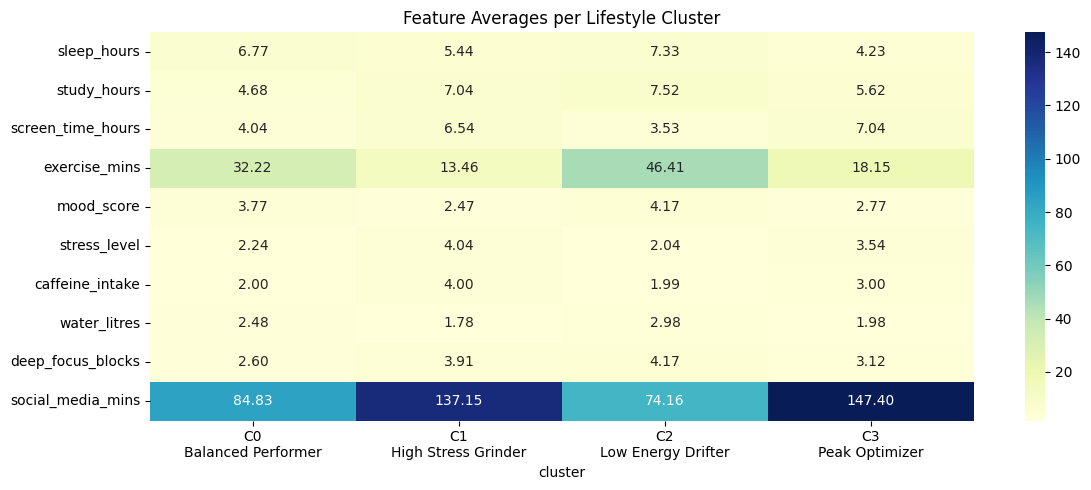

In [15]:
pipeline.evaluate_all()


In [16]:
pipeline.save_all()



💾 Saving all models to: /content/pulse_models
  💾 Saved: /content/pulse_models\productivity_model.pkl, /content/pulse_models\productivity_scaler.pkl
  💾 Saved burnout model files to: /content/pulse_models
  💾 Saved: kmeans_model.pkl, kmeans_scaler.pkl

✅ All models saved successfully!
  Files created:
    📁 burnout_feature_cols.pkl
    📁 burnout_label_encoder.pkl
    📁 burnout_model.pkl
    📁 burnout_scaler.pkl
    📁 kmeans_model.pkl
    📁 kmeans_scaler.pkl
    📁 productivity_model.pkl
    📁 productivity_scaler.pkl


## 🧪 Step 6 — Live Prediction Test

In [17]:
# Simulate a real user logging Day 1 data
new_user = {
    'sleep_hours'       : 5.0,
    'study_hours'       : 7.5,
    'screen_time_hours' : 6.0,
    'exercise_mins'     : 20,
    'mood_score'        : 3.0,
    'stress_level'      : 3.8,
    'caffeine_intake'   : 3,
    'water_litres'      : 1.8,
    'deep_focus_blocks' : 3,
    'social_media_mins' : 45,
    'is_weekend'        : 0,
    'day_of_week'       : 'Wednesday',
}

result = pipeline.predict(new_user)

print("=" * 50)
print("  🧠 PULSE Prediction Result")
print("=" * 50)
print(f"  Productivity Score : {result['productivity_score']} / 100")
print(f"  Burnout Risk       : {result['burnout_risk']}")
print(f"  Confidence         : {result['burnout_confidence']}")
print(f"  Persona            : {result['persona']}  (Cluster {result['cluster_id']})")
print("=" * 50)


  🧠 PULSE Prediction Result
  Productivity Score : 53.8 / 100
  Burnout Risk       : Medium
  Confidence         : {'High': '0.2%', 'Low': '0.5%', 'Medium': '99.3%'}
  Persona            : High Stress Grinder  (Cluster 1)


## 💡 Step 7 — Explainability (Why this score?)

In [18]:
class PulseExplainer:
    """
    Generates human-readable explanations for each prediction
    using Linear Regression coefficients as feature importance.
    """

    FEATURE_LABELS = {
        'sleep_hours'       : 'Sleep',
        'study_hours'       : 'Study Hours',
        'screen_time_hours' : 'Screen Time',
        'exercise_mins'     : 'Exercise',
        'mood_score'        : 'Mood',
        'stress_level'      : 'Stress Level',
        'caffeine_intake'   : 'Caffeine',
        'water_litres'      : 'Hydration',
        'deep_focus_blocks' : 'Deep Focus Sessions',
        'social_media_mins' : 'Social Media',
    }

    def __init__(self, productivity_model: ProductivityPredictor):
        self.model = productivity_model

    def explain(self, user_input: dict, top_n=3):
        coef   = self.model.model.coef_
        feats  = self.model.FEATURES

        # Scale user input to get contribution direction
        x      = pd.DataFrame([user_input])[feats]
        x_sc   = self.model.scaler.transform(x)[0]

        contributions = {
            feat: round(coef[i] * x_sc[i], 2)
            for i, feat in enumerate(feats)
        }

        sorted_contribs = sorted(contributions.items(), key=lambda x: x[1], reverse=True)
        positives = [(f, v) for f, v in sorted_contribs if v > 0][:top_n]
        negatives = [(f, v) for f, v in sorted_contribs if v < 0][-top_n:]

        print("\n💡 Why this score?")
        print("─" * 40)
        print(f"  ✅ Helping you (top {top_n}):")
        for feat, val in positives:
            print(f"     {self.FEATURE_LABELS.get(feat, feat):25s} +{val}")

        print(f"\n  ⚠️  Hurting you (top {top_n}):")
        for feat, val in negatives:
            print(f"     {self.FEATURE_LABELS.get(feat, feat):25s} {val}")


# ── Run ──
explainer = PulseExplainer(pipeline.productivity_model)
explainer.explain(new_user)



💡 Why this score?
────────────────────────────────────────
  ✅ Helping you (top 3):
     Study Hours               +5.63

  ⚠️  Hurting you (top 3):
     Mood                      -1.62
     Sleep                     -4.13
     Stress Level              -4.26
